In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import numpy as np
from Bio import SeqIO
plt.rcParams['figure.figsize'] = [10, 8]
np.random.seed(42)

In [54]:
large = 27; med = 18; small = 12
l_width = 3; m_width = 1.5; s_width = 0.7
params = {'axes.titlesize': large,
          'legend.fontsize': large,
          'legend.title_fontsize':large,
          'figure.figsize': (8, 5),
          'axes.labelsize': large,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large,
          'lines.linewidth': l_width,
          'lines.markersize': 10,
          'axes.linewidth': l_width,
          'xtick.major.size': 8,
          'ytick.major.size': 8,
          'xtick.minor.size': 4,
          'ytick.minor.size': 4,
          'xtick.major.width': m_width,
          'ytick.major.width': m_width,
          'xtick.minor.width': s_width,
          'ytick.minor.width': s_width,
          'grid.linewidth': m_width}
plt.rcParams.update(params)



In [55]:
def fasta_to_dataframe(file_path):
    # Parse the FASTA file into a list of dictionaries
    records = [
        {"id": record.id, "description": record.description, "sequence": str(record.seq)} 
        for record in SeqIO.parse(file_path, "fasta")
    ]
    
    # Convert to Pandas DataFrame
    return pd.DataFrame(records)

In [56]:
df_fasta=fasta_to_dataframe('../02_Sequence_Design_100K/designs/seqs/SDC_clean.fa')
df_fasta = df_fasta.iloc[1:]

df_fasta["sample_id"]=df_fasta["id"]
df_fasta.head()

,id,description,sequence,sample_id
1,sample_1,sample_1,MTLGSVEITKTDTNGNPLAGGVFSIVDSNGNVVKSNLVSDANGKIT...,sample_1
2,sample_2,sample_2,ATLGSVTITKTDTNGNPLAGAVFDIKDSNGNTVKSNLVSDANGTIT...,sample_2
3,sample_3,sample_3,ATLGSVTITKTDTNGNPLAGAVFSIVDSNGNTVKSNLVSDANGTIT...,sample_3
4,sample_4,sample_4,ATLGSVTITKTDTNGNPLAGAVFSIVDSNGNTVKSNLVSDANGTIT...,sample_4
5,sample_5,sample_5,MTLGSLKITKTDENGNPLAGGVFSIVDSSGNVVKSNLVSDANGTIN...,sample_5


In [57]:
df_esm=pd.read_csv('../03_ESM_100K/structure_metrics.csv')
df_esm=pd.merge(df_fasta, df_esm, on='sample_id')

df_esm.head()
print(df_esm.shape[0])

100000


In [58]:
df_stability=pd.read_csv('../03_ESM_100K/ensemble_fold_stability.csv')
df_stability["dG(Kcal/mol)"]=df_stability["mean"]
df_stability.head()

,sample_id,model_1,model_2,model_3,mean,std,dG(Kcal/mol)
0,sample_1,8.7823,9.4187,8.8172,9.0061,0.3578,9.0061
1,sample_2,7.6896,8.2380,7.7694,7.8990,0.2963,7.8990
2,sample_3,8.2142,8.5654,8.3614,8.3803,0.1764,8.3803
3,sample_4,9.0133,9.4970,9.0881,9.1995,0.2604,9.1995
4,sample_5,8.6515,9.2156,8.7815,8.8829,0.2954,8.8829


In [59]:
df_esm.shape,df_stability.shape

((100000, 6), (100000, 7))

In [60]:
df_esm_stability=pd.merge(df_stability, df_esm, on='sample_id')


df_esm_stability.shape

(100000, 12)

In [61]:
print ("# of sequences:",df_esm_stability.shape[0])
final_df = df_esm_stability[["sample_id","sequence", "pLDDT","dG(Kcal/mol)"]]
print ("# of sequences:",final_df.shape[0])
final_df.head()

# of sequences: 100000
# of sequences: 100000


,sample_id,sequence,pLDDT,dG(Kcal/mol)
0,sample_1,MTLGSVEITKTDTNGNPLAGGVFSIVDSNGNVVKSNLVSDANGKIT...,93.1,9.0061
1,sample_2,ATLGSVTITKTDTNGNPLAGAVFDIKDSNGNTVKSNLVSDANGTIT...,84.4,7.8990
2,sample_3,ATLGSVTITKTDTNGNPLAGAVFSIVDSNGNTVKSNLVSDANGTIT...,85.7,8.3803
3,sample_4,ATLGSVTITKTDTNGNPLAGAVFSIVDSNGNTVKSNLVSDANGTIT...,92.4,9.1995
4,sample_5,MTLGSLKITKTDENGNPLAGGVFSIVDSSGNVVKSNLVSDANGTIN...,93.0,8.8829


In [62]:
final_df.to_csv('round2_100K_all.csv')

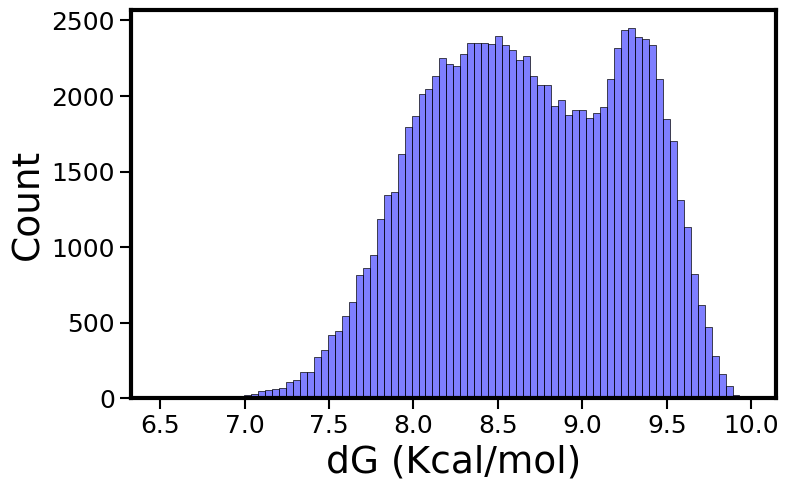

In [32]:
sns.histplot(final_df["dG(Kcal/mol)"],alpha=0.5,color='b')
plt.xlabel("dG (Kcal/mol)")
plt.tight_layout()
plt.savefig('ddg_distribution.png')

# of sequences selected: 31209


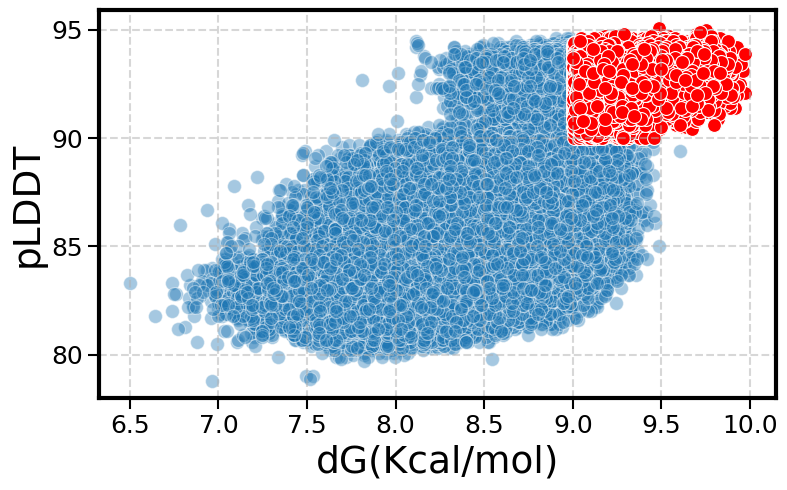

In [53]:
df=final_df.copy()
df_select=df[((df["pLDDT"]>=90) & (df["dG(Kcal/mol)"]>=9.0))]
sns.scatterplot(data=df,y='pLDDT',x='dG(Kcal/mol)',alpha=0.4)
plt.xlabel("dG(Kcal/mol)")
sns.scatterplot(data=df_select,x='dG(Kcal/mol)',y='pLDDT',color="red")
plt.grid(lw=1.5,ls="--",alpha=0.5)
print ("# of sequences selected:",df_select.shape[0])
plt.tight_layout()
plt.savefig('scatter_selected.png')